# Autoencoder Experiment

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline

## Loading MNIST Dataset

In [2]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

dataset = MNIST(root='data/', download=True, transform=ToTensor())
test_dataset = MNIST(root='data/', train=False, transform=ToTensor())
len(dataset), len(test_dataset)

(60000, 10000)

## Creating Training and Test Data Loaders

In [3]:
# setting a global seed
SEED = 42
torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

In [4]:
from torch.utils.data.dataloader import DataLoader

batch_size = 128

train_loader = DataLoader(dataset, batch_size, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size, generator=g)

### Visualize Data

images.shape: torch.Size([128, 1, 28, 28])


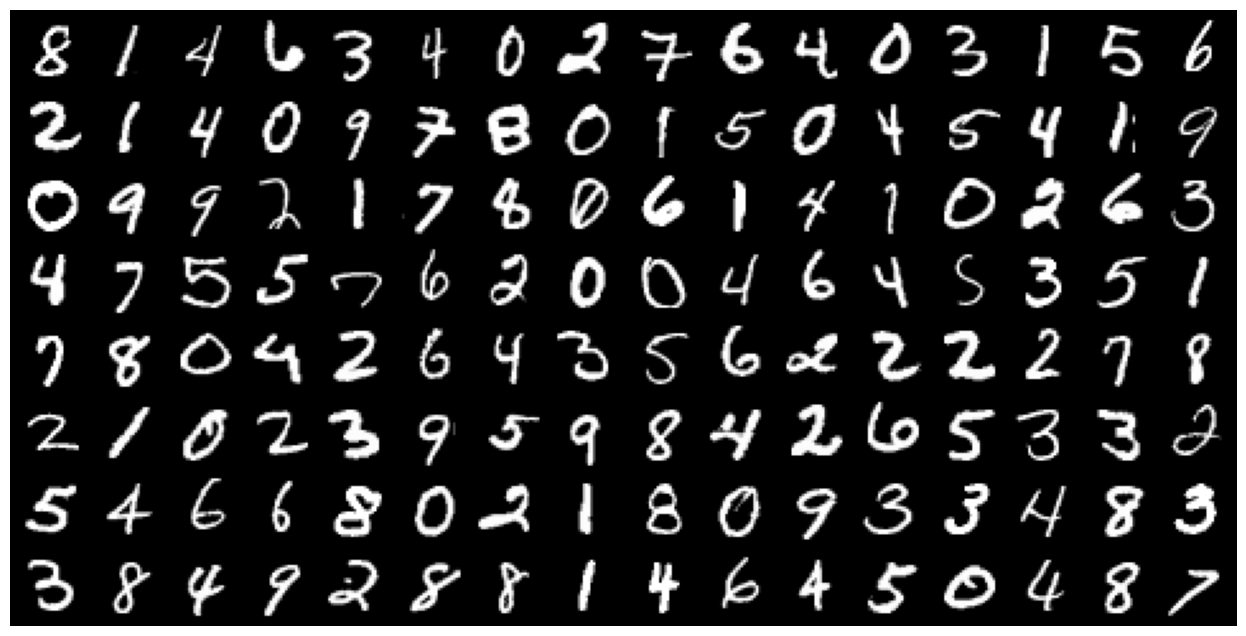

In [5]:
from torchvision.utils import make_grid

for images, _ in train_loader:
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))
    break

images.shape: torch.Size([128, 1, 28, 28])


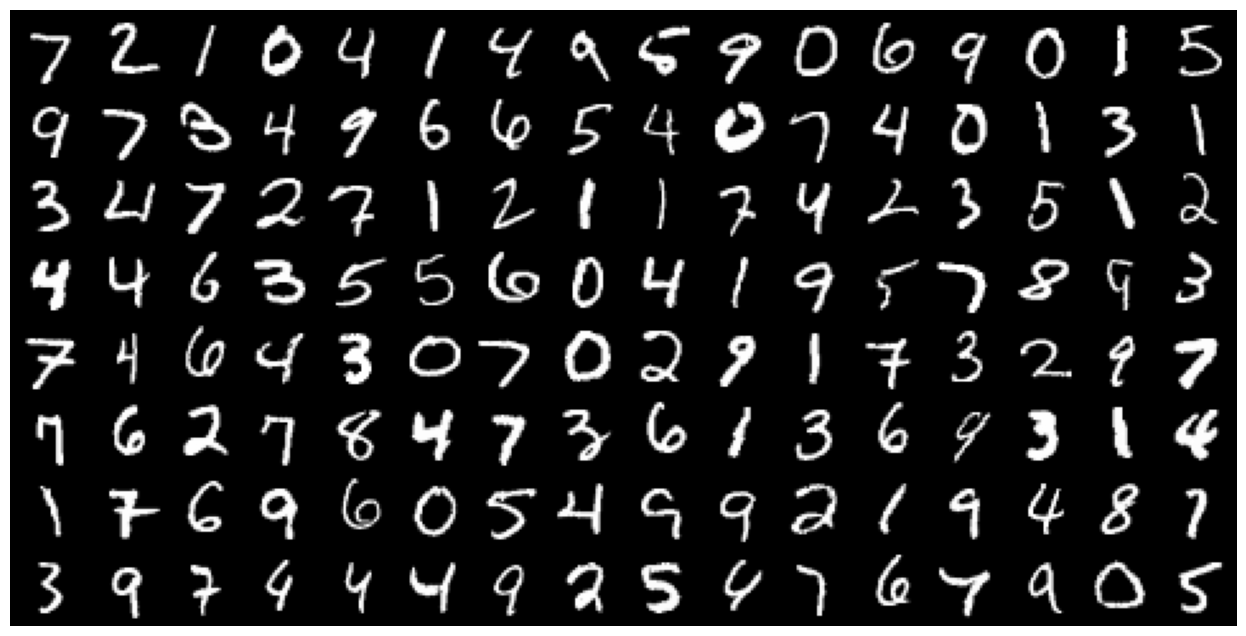

In [6]:
for images, _ in test_loader:
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))
    break

## Experiments

### Experiment 1: Training Loss

In [7]:
# time in minutes and seconds
def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

In [8]:
from autoencoder import AutoEncoder
from time import time

model = AutoEncoder()

# 10 epochs
start_time = time() # start the timer
history = model.fit(train_loader=train_loader, epochs=10)
elapsed = time() - start_time
recorded_time(elapsed)

Epoch [1/10] train_loss: 0.0609
Epoch [2/10] train_loss: 0.0219
Epoch [3/10] train_loss: 0.0165
Epoch [4/10] train_loss: 0.0134
Epoch [5/10] train_loss: 0.0113
Epoch [6/10] train_loss: 0.0098
Epoch [7/10] train_loss: 0.0088
Epoch [8/10] train_loss: 0.0081
Epoch [9/10] train_loss: 0.0075
Epoch [10/10] train_loss: 0.0071
time: 17m 45s


In [9]:
print(history)

[0.06092477962374687, 0.0219256691634655, 0.016502724960446358, 0.013391383923590183, 0.011310752481222153, 0.009838140569627285, 0.008809900842607021, 0.00806757714599371, 0.007516295183449984, 0.007111841347068548]


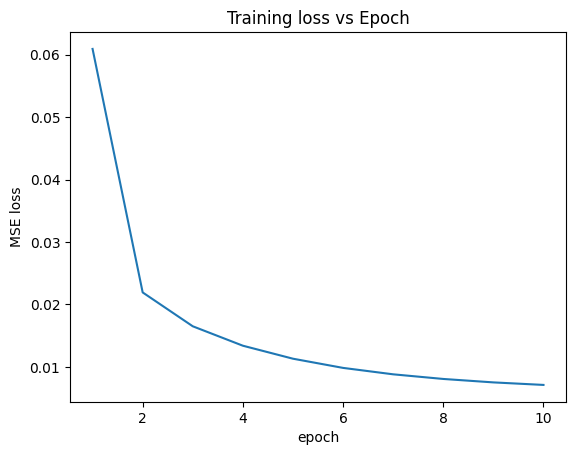

In [10]:
import numpy as np

plt.plot(np.linspace(1, 10, 10), history)
plt.title("Training loss vs Epoch")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

### Experiment 2: Visual Results

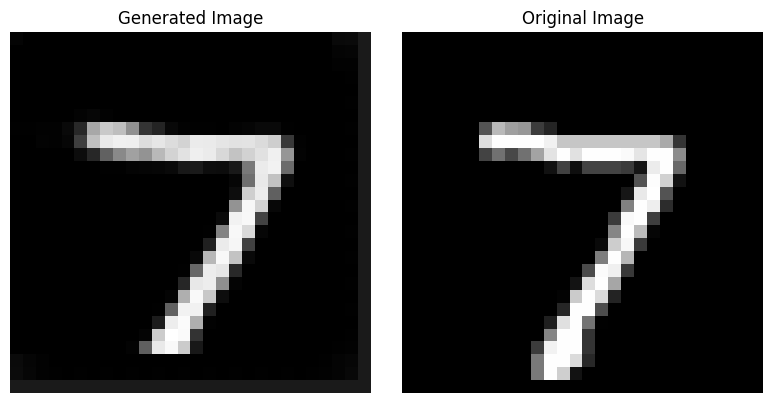

In [11]:
image, _ = test_dataset[0]

image = image.unsqueeze(0)

output_image = model(image)
model.visualize_result(output_image[0], image[0])

#### batches of reconstruction

In [12]:
images, _ = next(iter(test_loader))

#images = [image.unsqueeze(0) for image in images]

output_images = model(images)

Original Images


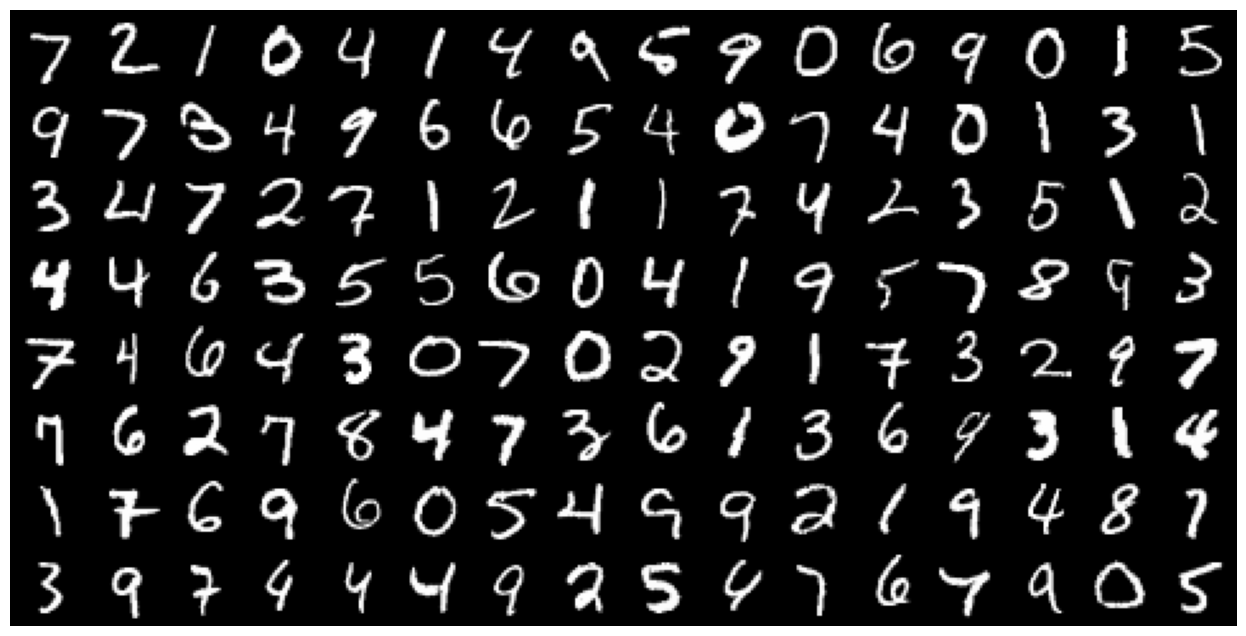

In [13]:
# Original Images
print("Original Images")
plt.figure(figsize=(16,8))
plt.axis('off')
plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))

Original Images


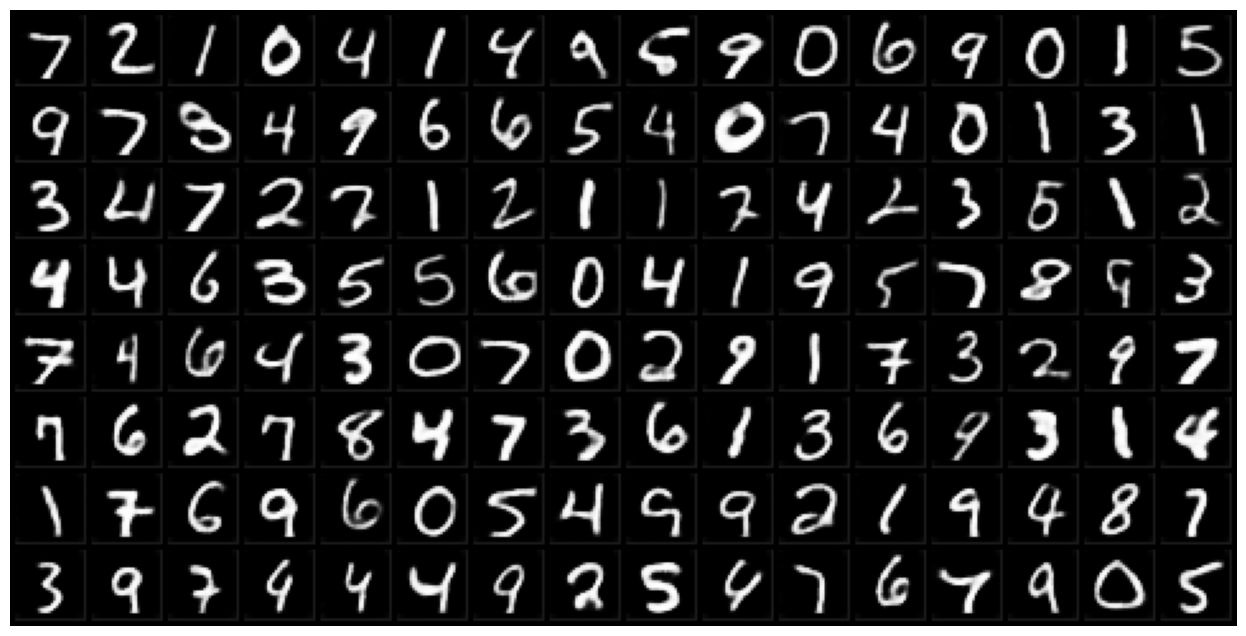

In [14]:
# Reconstruction Images
print("Original Images")
plt.figure(figsize=(16,8))
plt.axis('off')
plt.imshow(make_grid(output_images, nrow=16).permute((1,2,0)))

### Experiment 3: Different Latent Dimensions

In [15]:
from autoencoder import AutoEncoder
from time import time

# latent_dim = 8
model_8 = AutoEncoder(latent_dim=8)

# 10 epochs
start_time = time() # start the timer
history = model_8.fit(train_loader=train_loader, epochs=10)
elapsed = time() - start_time
recorded_time(elapsed)

Epoch [1/10] train_loss: 0.0905
Epoch [2/10] train_loss: 0.0434
Epoch [3/10] train_loss: 0.0366
Epoch [4/10] train_loss: 0.0322
Epoch [5/10] train_loss: 0.0289
Epoch [6/10] train_loss: 0.0266
Epoch [7/10] train_loss: 0.0248
Epoch [8/10] train_loss: 0.0236
Epoch [9/10] train_loss: 0.0227
Epoch [10/10] train_loss: 0.0220
time: 13m 23s


In [16]:
from autoencoder import AutoEncoder
from time import time

# latent_dim = 16
model_16 = AutoEncoder(latent_dim=16)

# 10 epochs
start_time = time() # start the timer
history = model_16.fit(train_loader=train_loader, epochs=10)
elapsed = time() - start_time
recorded_time(elapsed)

Epoch [1/10] train_loss: 0.0749
Epoch [2/10] train_loss: 0.0312
Epoch [3/10] train_loss: 0.0248
Epoch [4/10] train_loss: 0.0210
Epoch [5/10] train_loss: 0.0182
Epoch [6/10] train_loss: 0.0163
Epoch [7/10] train_loss: 0.0149
Epoch [8/10] train_loss: 0.0140
Epoch [9/10] train_loss: 0.0132
Epoch [10/10] train_loss: 0.0127
time: 13m 42s


In [17]:
from autoencoder import AutoEncoder
from time import time

# latent_dim = 64
model_64 = AutoEncoder(latent_dim=64)

# 10 epochs
start_time = time() # start the timer
history = model_64.fit(train_loader=train_loader, epochs=10)
elapsed = time() - start_time
recorded_time(elapsed)

Epoch [1/10] train_loss: 0.0715
Epoch [2/10] train_loss: 0.0240
Epoch [3/10] train_loss: 0.0178
Epoch [4/10] train_loss: 0.0140
Epoch [5/10] train_loss: 0.0113
Epoch [6/10] train_loss: 0.0094
Epoch [7/10] train_loss: 0.0081
Epoch [8/10] train_loss: 0.0071
Epoch [9/10] train_loss: 0.0064
Epoch [10/10] train_loss: 0.0058
time: 17m 40s


In [18]:
from autoencoder import AutoEncoder
from time import time

# latent_dim = 128
model_128 = AutoEncoder(latent_dim=128)

# 10 epochs
start_time = time() # start the timer
history = model_128.fit(train_loader=train_loader, epochs=10)
elapsed = time() - start_time
recorded_time(elapsed)

Epoch [1/10] train_loss: 0.0627
Epoch [2/10] train_loss: 0.0207
Epoch [3/10] train_loss: 0.0154
Epoch [4/10] train_loss: 0.0122
Epoch [5/10] train_loss: 0.0100
Epoch [6/10] train_loss: 0.0084
Epoch [7/10] train_loss: 0.0073
Epoch [8/10] train_loss: 0.0065
Epoch [9/10] train_loss: 0.0058
Epoch [10/10] train_loss: 0.0054
time: 19m 5s


#### visualize results of different latent dimensions

In [19]:
def display_difference(image, model):
    
    image = image.unsqueeze(0)
    
    output_image = model(image)
    model.visualize_result(output_image[0], image[0])

In [20]:
# five images
image1, _ = test_dataset[0]
image2, _ = test_dataset[1]
image3, _ = test_dataset[10]
image4, _ = test_dataset[100]
image5, _ = test_dataset[1000]
images = [image1, image2, image3, image4, image5]

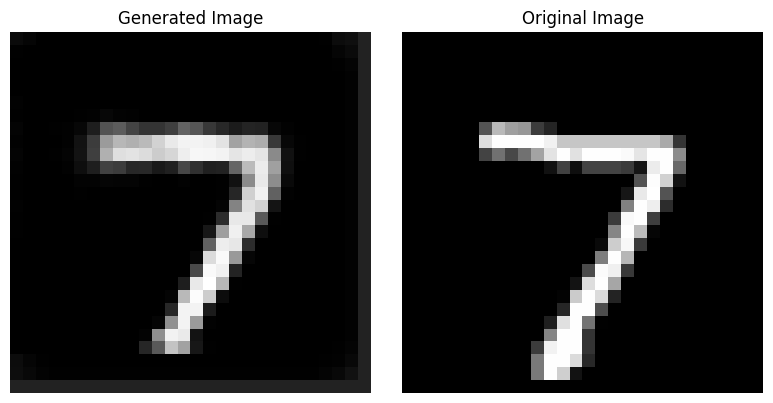

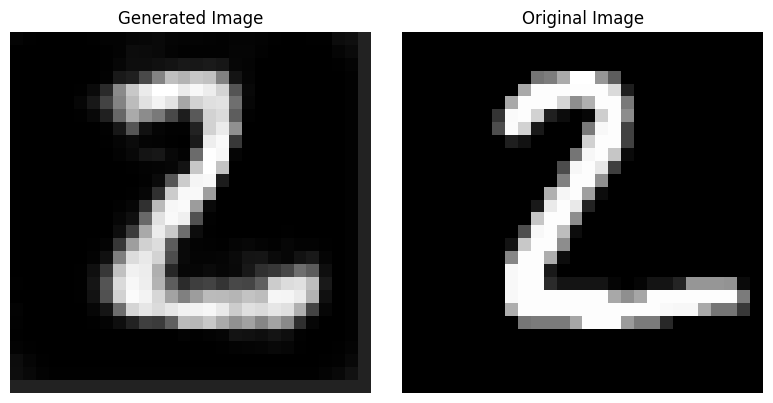

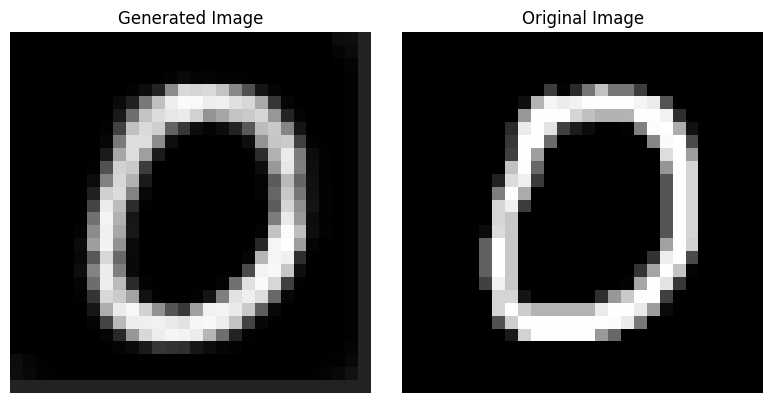

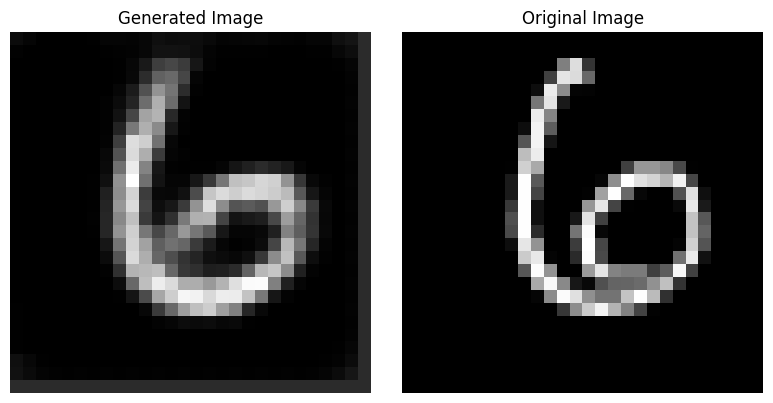

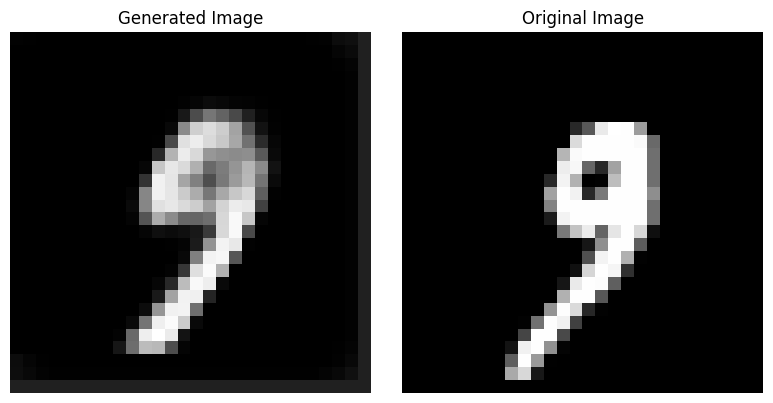

In [21]:
# model with latent_dim = 8
for image_i in [image1, image2, image3, image4, image5]:
    display_difference(image_i, model_8)

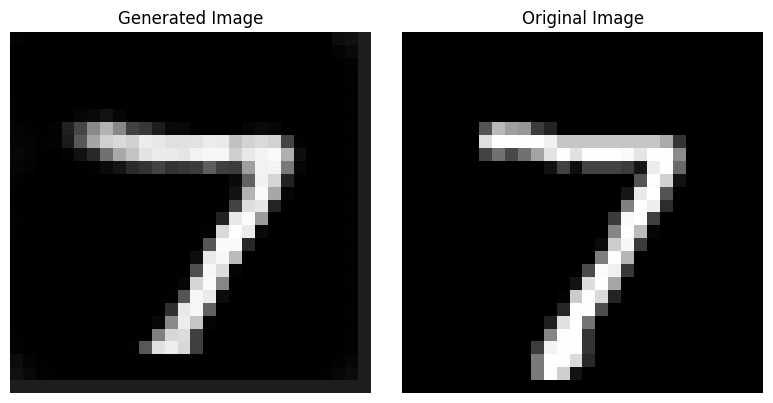

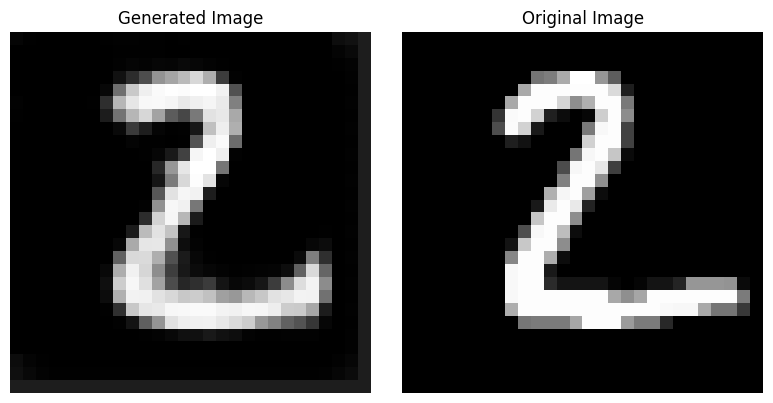

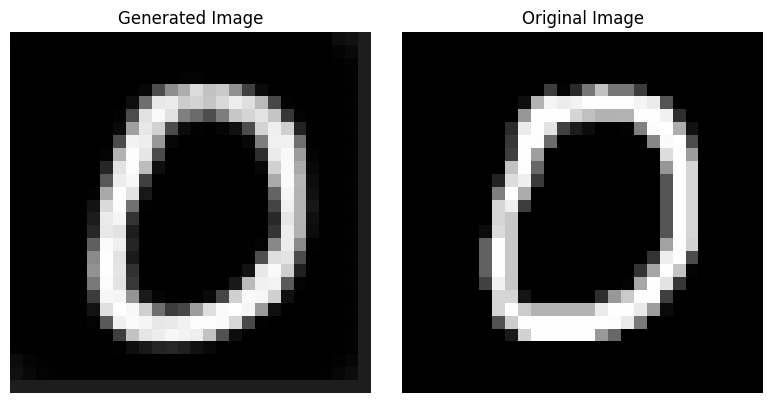

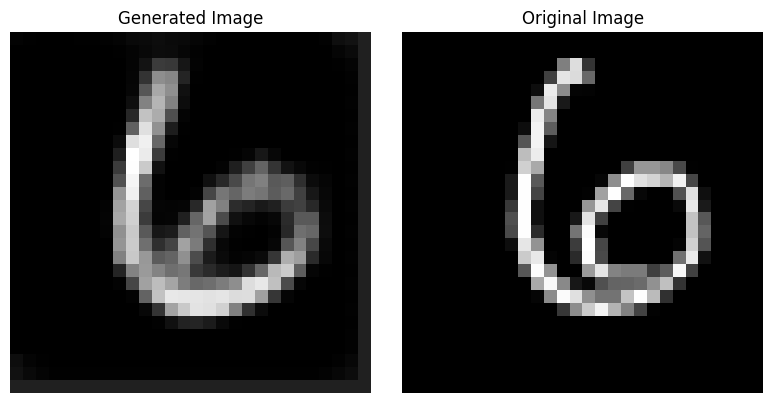

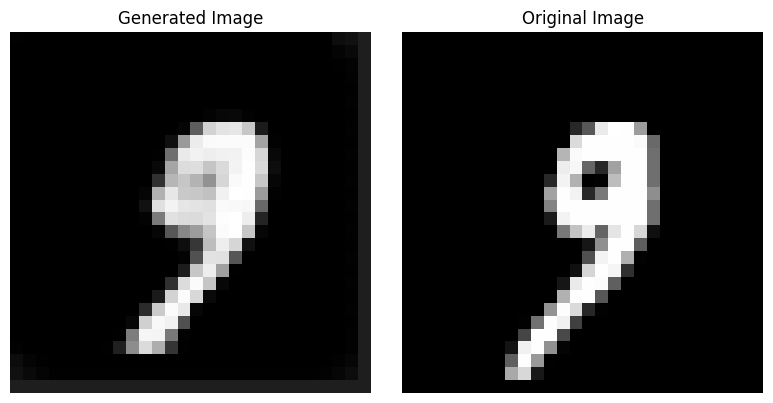

In [22]:
# model with latent_dim = 16
for image_i in [image1, image2, image3, image4, image5]:
    display_difference(image_i, model_16)

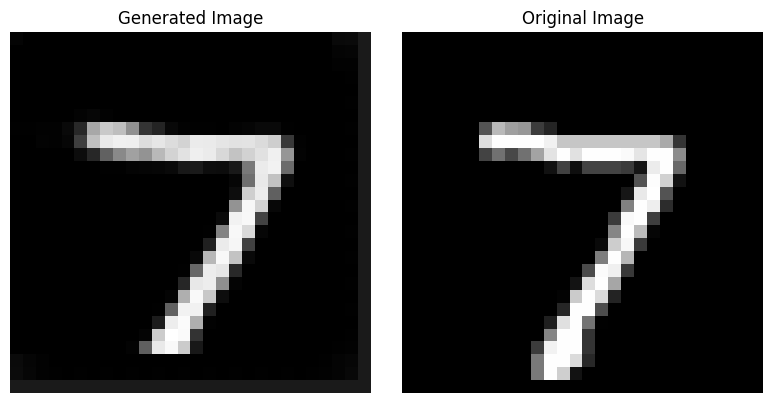

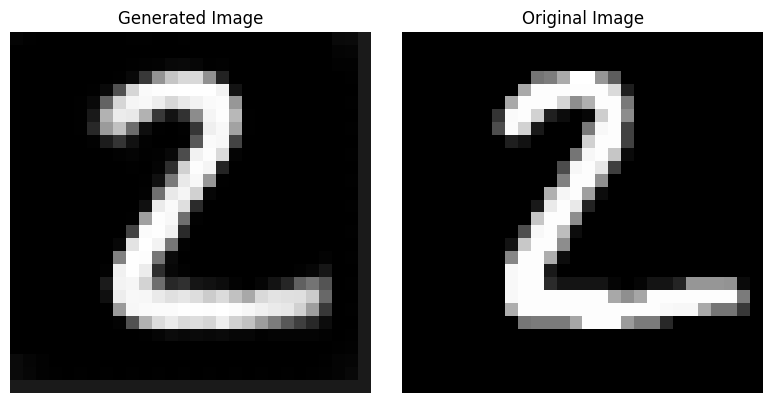

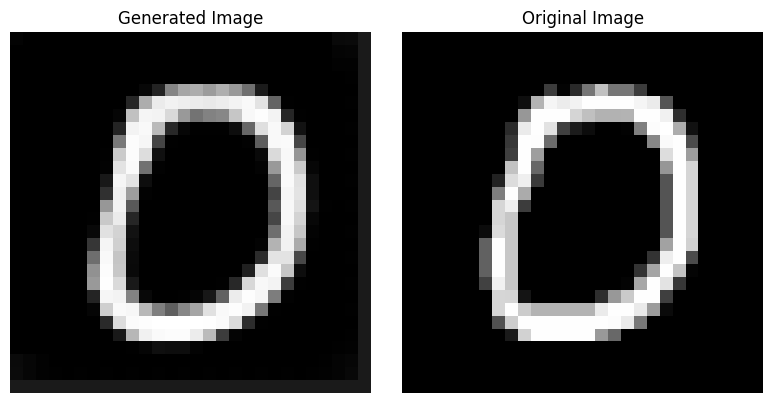

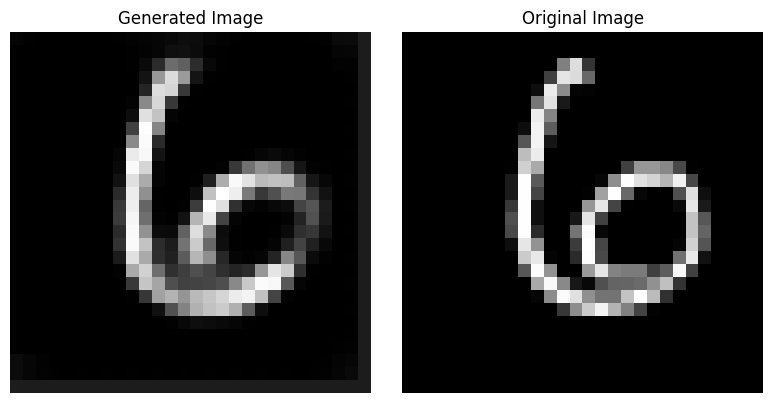

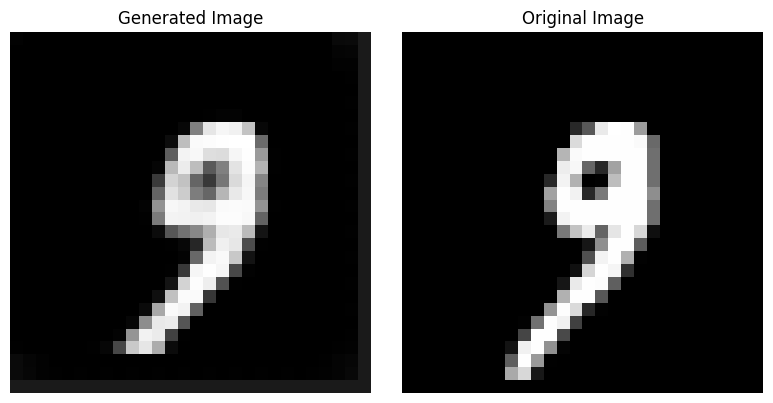

In [23]:
# model with latent_dim = 32
for image_i in images:
    display_difference(image_i, model)

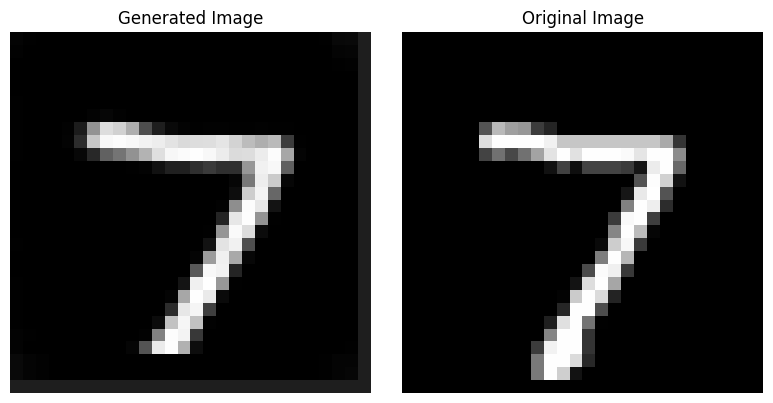

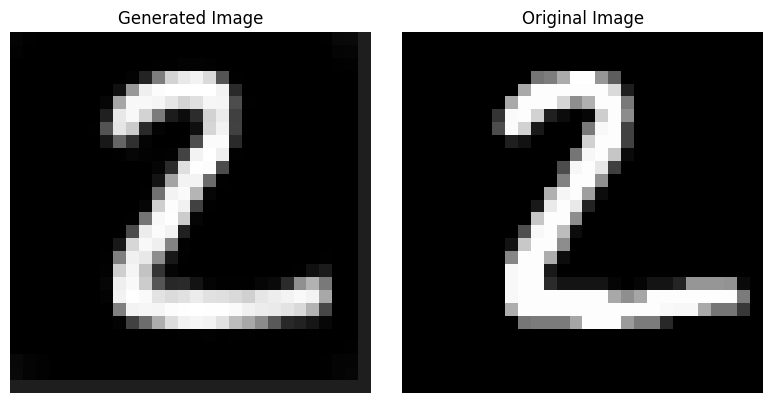

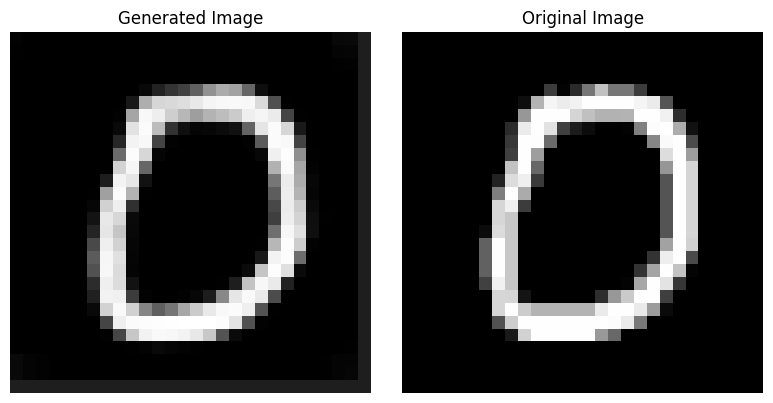

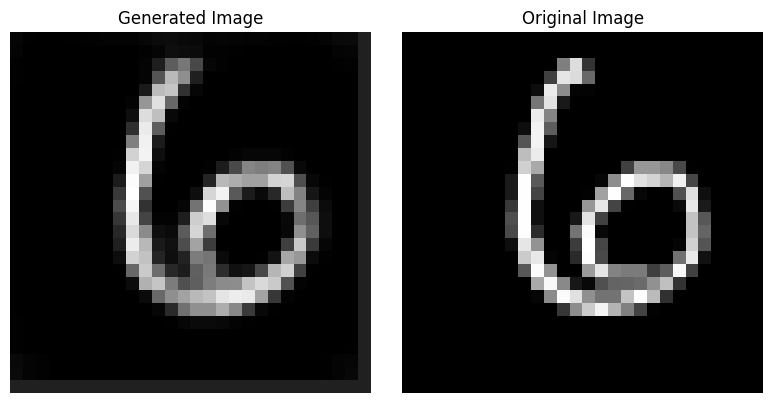

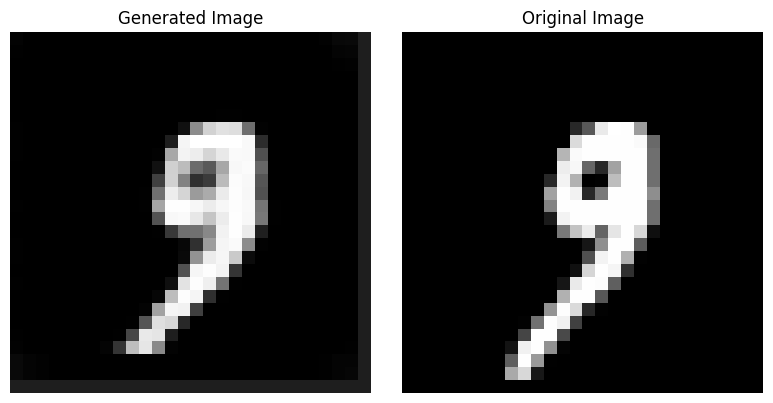

In [24]:
# model with latent_dim = 64
for image in images:
    display_difference(image, model_64)

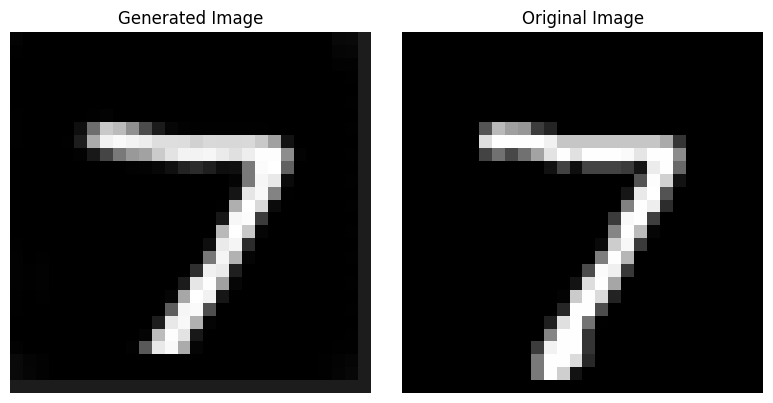

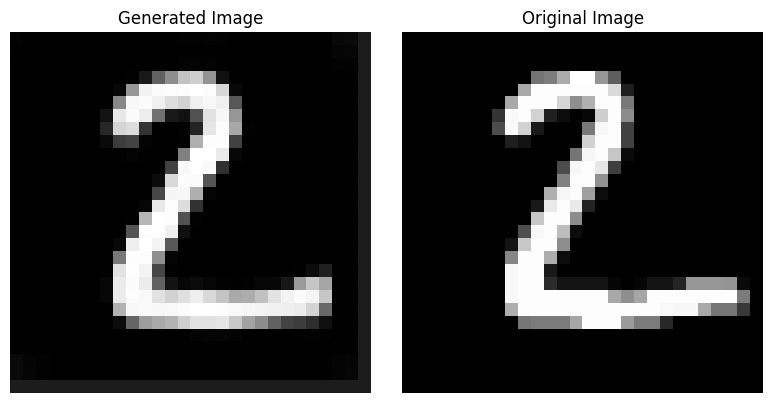

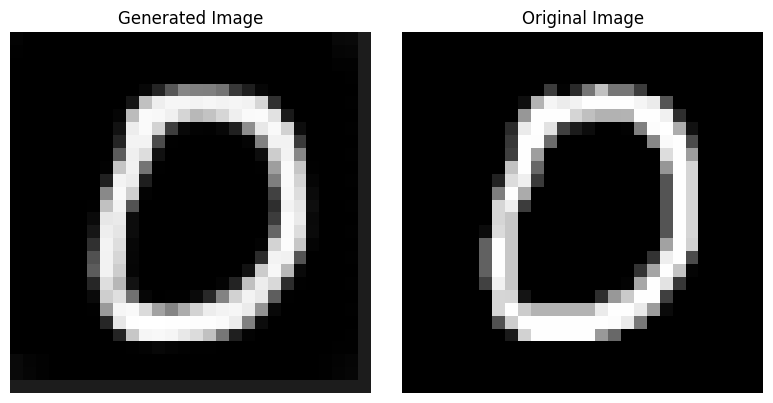

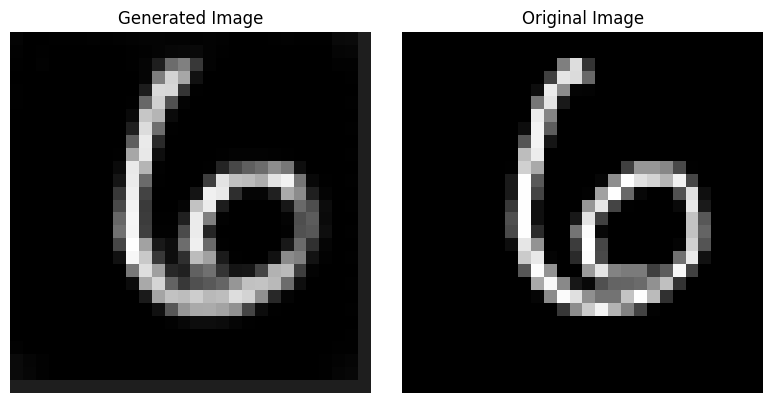

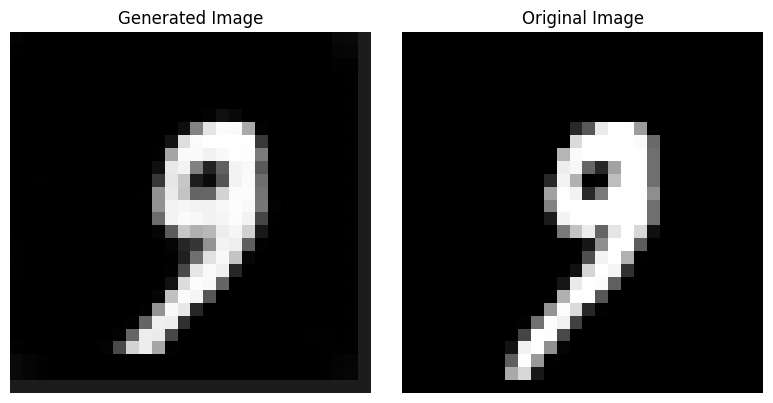

In [25]:
# model with latent_dim = 128
for image in images:
    display_difference(image, model_128)

### Experiment 4: PCA

In [26]:
latent_vectors = []
labels_list = []

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for images, labels in test_loader:
        # Move the entire batch to the device
        z = model.encoder(images.to(device))
        
        # Move back to CPU and convert to list/numpy for storage
        latent_vectors.append(z.cpu())
        labels_list.append(labels)

# Concatenate all batches into two large tensors
latent_vectors = torch.cat(latent_vectors, dim=0)
labels = torch.cat(labels_list, dim=0)

print(latent_vectors.shape) # Should be [10000, latent_dim]
print(labels.shape)         # Should be [10000]

torch.Size([10000, 32])
torch.Size([10000])


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

latent_vectors_pca = pca.fit_transform(latent_vectors)

print(f"Original shape: {latent_vectors.shape}")      # (10000, 32)
print(f"Reduced shape: {latent_vectors_pca.shape}")   # (10000, 2)


Original shape: torch.Size([10000, 32])
Reduced shape: (10000, 2)


In [28]:
print(latent_vectors_pca[:10])

[[ -7.34761489   9.41305204]
 [  1.92319588 -15.60246927]
 [-13.99099043  -7.39017015]
 [ 16.74589087   2.51938863]
 [  6.4568436   14.74188349]
 [-16.27078961  -6.89373727]
 [ -5.55299596  11.31745522]
 [ -4.75411456   9.83752605]
 [  4.71007196   5.36195956]
 [ -2.64547089   9.01182648]]


In [29]:
labels_pca = labels.detach().cpu().numpy()
print(labels_pca.shape)

(10000,)


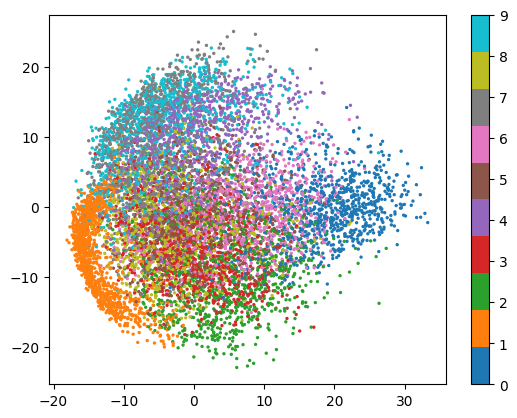

In [30]:
# Using 'tab10'
plt.scatter(latent_vectors_pca[:, 0], latent_vectors_pca[:, 1], c=labels_pca, cmap='tab10', s=2)
plt.colorbar(ticks=range(10))
plt.show()

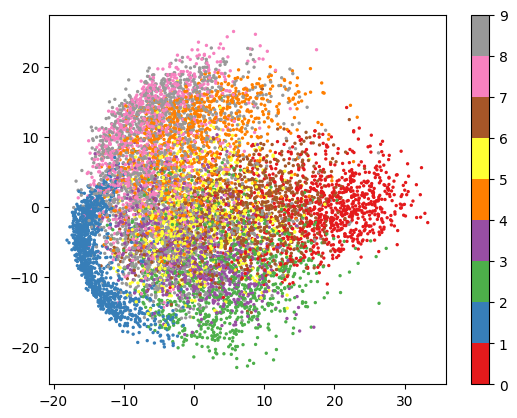

In [31]:
# Using 'Set1'
plt.scatter(latent_vectors_pca[:, 0], latent_vectors_pca[:, 1], c=labels_pca, cmap='Set1', s=2)
plt.colorbar(ticks=range(10))
plt.show()

### Experiment 5: Interpolation

In [32]:
# find first 0 and 9 latent vectors
zero_latent_vector = None
nine_latent_vector = None

index = 0
while index < len(labels_pca):
    if labels[index] == 0:
        zero_latent_vector = latent_vectors[index, :]
    if labels[index] == 9:
        nine_latent_vector = latent_vectors[index, :]
    if zero_latent_vector != None and nine_latent_vector != None:
        break
    index += 1

print("zero:", zero_latent_vector)
print("nine:", nine_latent_vector)

zero: tensor([  2.3320,  -1.6068,   2.3940,   1.9958,  -0.5467,   4.5660,   1.2679,
          6.0619,  -5.6833,  -7.1092,  -9.6821,   0.8529,  -3.4159,  -4.0832,
         12.2592,   3.1051,  -0.5954,  -8.8952,   8.0021,  -2.8369,  -1.6515,
          4.3692,   4.6642,  -2.6643,   9.0363,  -5.7470,   2.6767,  -3.2264,
        -15.9726,  -4.2608,  -8.0350,  -0.6165])
nine: tensor([  6.5817,   7.1274,   5.0602,  -5.1884,  -5.7423,   6.0180,  -2.8422,
         -1.1377,  -5.3768,   1.7607,   0.8191,  -2.2515,   1.7060,   3.0154,
         -1.4637,  -3.7952,  -2.2581,  -4.3368,   4.0667,   3.3702,   8.1221,
         -1.5078,   1.4001,   6.0402,   1.5844,  -6.9606,   5.2656,   5.5795,
         -5.2259,  -0.2771, -10.2909,   8.4585])


#### Interpolation Formula: $z = (1 - t)z_1 + tz_2$ 
##### Where $z$ is a number from 0 to 9, and generated by the given formula.

In [33]:
def interpolate(z_1, z_2, t):
    return (1 - t)*z_1 + t*z_2

In [59]:
# generating digits using interpolation
images = []
for t in range(0, 10):
    latent_vector = interpolate(zero_latent_vector, nine_latent_vector, t/9)
    image = model.decoder(latent_vector.unsqueeze(0).detach().cpu())
    images.append(image.squeeze(0))

len(images)

10

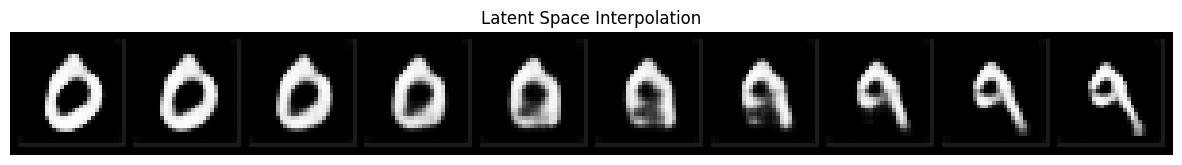

In [60]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

image_tensor = torch.stack(images).detach().cpu()

grid = make_grid(image_tensor, nrow=10) # 10 images per row

plt.figure(figsize=(15, 5))
plt.imshow(grid.permute(1, 2, 0)) 
plt.axis('off')
plt.title("Latent Space Interpolation")
plt.show()
